# 06c — Faithful G=28 thesis reproduction (barycenter averaging)

**What this notebook is.** A faithful reproduction of the thesis-era G=28 barycenter
analysis on the **embedding-level** symbolic representation (median L≈ 5162 symbols per
participant): the four thesis figure families (cohort chronograms, per-group barycenters,
alignment ribbons, pairwise distance) and a re-test of the group-discrimination claim.

**What changed vs the previous 06c.** The previous version resampled every sequence to
`L=64` (`upsample_sequence(s, 64)`) *before* the barycenter / distance / classification,
collapsing the embedding-level chronogram into a 64-cell strip and destroying the temporal
ordering the alignment barycenter is meant to exploit. This rewrite keeps the
embedding-level sequences for the figures and **sweeps the resample length** for the
classification, so we can see whether the prior "frequency beats alignment" result was an
`L=64` artifact.

**Representation.** `int_cat_segm_embedding_labels` — 27 named cooking-action categories +
background (code 0), built by `vocab.add_category_columns` (the thesis pyramid pipeline).
Ground cost `D_G` = the 28×28 temporal-occurrence Wasserstein matrix. Barycenter engine =
the installed (forked) aeon `elastic_barycenter_average` with `distance='rtwe'`,
`precomputed_distances=D_G`, `integers=True` (argmax / mode update for discrete states).

In [1]:
%load_ext autoreload
%autoreload 2
import os, json, numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
os.environ.setdefault('NUMBA_THREADING_LAYER', 'workqueue')   # hardened-kernel large-L safety (S2; mirrors 06/06d/06e)
warnings.filterwarnings('ignore')
from IPython.display import display
from joblib import load, dump
from smartflat.utils.utils_io import get_data_root
from smartflat.utils.utils import upsample_sequence
from smartflat.utils.utils_visualization import plot_chronogames
from smartflat.constants import incomplete_clinical_administrations
from smartflat.features.symbolization.utils import fix_clinical_diagnosis
from smartflat.features.symbolization.utils_dataset import get_experiments_dataframe
from smartflat.features.symbolic_barycenter import vocab
from smartflat.features.symbolic_barycenter import baselines as B
from smartflat.features.symbolic_barycenter.baselines import make_patient_control_labels
from smartflat.features.symbolic_barycenter.visualization import (
    plot_chronogram_alignment, plot_pairwise_twe_distances_by_group, compute_alignment_path)
from smartflat.engine.distances._rtwe import rtwe_pairwise_distance
from aeon.clustering.averaging import elastic_barycenter_average
plt.rcParams['figure.dpi'] = 110

ANN, RND, CFG = 'samperochon', 8, 'SymbolicSourceInferenceGoldConfig'
NU, LMBDA, OFFSET = 1e-4, 0.1, 0.3        # thesis G=28 hyperparameters
FIG_L, ALN_L = 3000, 1500                  # figure-rendering lengths (NOT the classification L)
OUT = os.path.join(get_data_root(), 'outputs', 'symbolic_barycenter', 'g28'); os.makedirs(OUT, exist_ok=True)
print('output dir:', OUT)

output dir: /Users/samperochon/github-repositories/smartflat/data/data-gold-final/outputs/symbolic_barycenter/g28


In [2]:
# Build (or load cached) the embedding-level G=28 representation + ground cost.
cache_df, cache_code = os.path.join(OUT, 'g28_full_with_cat.pkl'), os.path.join(OUT, 'category_codes.json')
cache_D = os.path.join(OUT, 'D_G_cat_temporal_raw.npy')
if os.path.exists(cache_df) and os.path.exists(cache_code):
    dff = load(cache_df); code = json.load(open(cache_code)); print('loaded cached G=28 dataframe')
else:
    dff = get_experiments_dataframe(experiment_config_name=CFG, annotator_id=ANN, round_number=RND,
                                    return_symbolization=True, return_data_only=True)
    dff, code, _ = vocab.add_category_columns(dff, CFG, ANN, RND)
    dump(dff, cache_df); json.dump(code, open(cache_code, 'w')); print('built + cached G=28 dataframe')
code_to_label = [None]*len(code)
for k, v in code.items(): code_to_label[v] = k

# Ground cost = 28x28 temporal-occurrence Wasserstein (thesis '_None_cat_final').
if os.path.exists(cache_D):
    D_raw = np.load(cache_D)
else:
    rnd8 = os.path.join(get_data_root(),'experiments','symbolization-gold','faissc_inference_symbolization',ANN,'round_8')
    D_raw = np.load(os.path.join(rnd8,'D_ttrr_pc_wasserstein-1_square_loss_128_multiplicative_1_None_cat_final.npy'))
D_G_cat = vocab.compute_distance_matrix(D_raw, method='max_rows_cols_pre', offset_value=OFFSET)
G = len(code)
print('G =', G, '| D_G_cat', D_G_cat.shape, '| range [%.3f, %.3f]' % (D_G_cat.min(), D_G_cat.max()))

loaded cached G=28 dataframe
G = 28 | D_G_cat (28, 28) | range [0.000, 1.000]


In [3]:
# --- sanity gate: HARD-STOP unless the representation is embedding-level G=28 ---
lens = dff['cat_segm_embedding_labels'].apply(len)
uniq = np.unique(np.hstack(dff['cat_segm_embedding_labels'].values))
assert lens.median() > 1000, f'sequences are not embedding-level (median {lens.median()})'
assert len(uniq) == G == 28, f'expected 28 categories, got {len(uniq)}'
print('embedding-level length: min %d  median %d  max %d' % (lens.min(), int(lens.median()), lens.max()))
print('vocabulary (%d): %s' % (len(uniq), sorted(uniq.tolist())))

# --- analysis cohort (clinical filter, mirrors NB06 cell 5) ---
df = fix_clinical_diagnosis(dff.copy())
df = df[~df['participant_id'].isin(incomplete_clinical_administrations.keys())]
df.sort_values('task_number_int', ascending=True, inplace=True)
df = df[df['pathologie'].isin(['HEALTHY', 'RIL', 'TBI'])]
df.drop_duplicates(subset=['trigram'], keep='first', inplace=True)
df = df.reset_index(drop=True)
df['group_folder'] = df['pathologie'].map({'HEALTHY': 0, 'TBI': 1, 'RIL': 2})
mapping_labels_int = dict(code)   # name -> int (0..27), '-1' -> 0
print('cohort:', df.groupby('pathologie').size().to_dict())

embedding-level length: min 2292  median 5162  max 10519
vocabulary (28): ['-1', 'break chocolate', 'break eggs', 'butter', 'clean hands', 'exogeneous', 'fridge', 'look kitchen', 'look shelf', 'look window', 'manipulate oven', 'merge butter chocolate', 'merge flour/eggs/sugar', 'merge flour/sugar', 'merge white eggs', 'open box ingredients', 'open butter/chocolate', 'plug mixer', 'poor dough into pan', 'poor flour/sugar', 'prepare mixer', 'recipe', 'setting oven', 'talking', 'use balance', 'use measuring cup', 'use mixer', 'use sink']
cohort: {'HEALTHY': 24, 'RIL': 37, 'TBI': 59}


## (a) Cohort chronograms — embedding-level, time-calibrated, named G=28

Each row is one participant; x-axis calibrated to minutes (`time_calibration='embeddings'`).
The first call locks the categorical colormap (`cmap`/`norm`/`boundaries`/`mapping_labels_int`),
reused by every later panel so colors are stable. Compare to the thesis cohort chronogram
(dense, ~0–40 min) — versus the 64-cell strips the L=64 pipeline produced.

Mapping string labels to integers for visualization


Label range: [0-27] (28 unique labels)
dffds


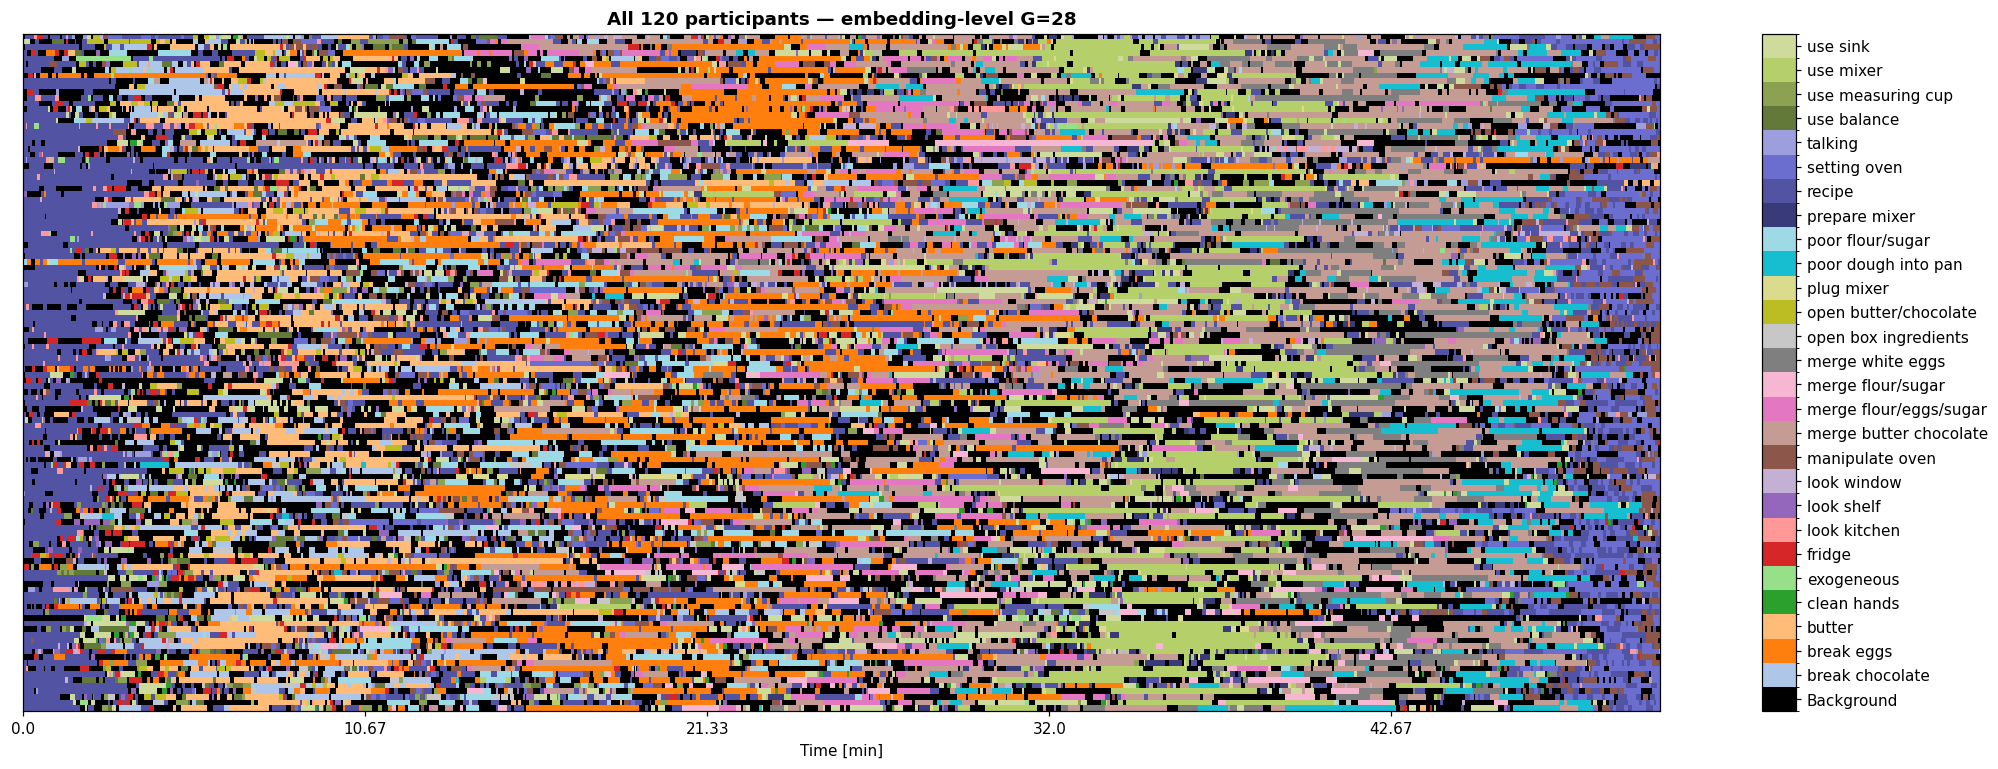

In [4]:
fig, ax = plt.subplots(figsize=(24, 8))
idx, cmap, norm, boundaries, mli = plot_chronogames(
    df, labels_col='cat_segm_embedding_labels', n_t_max=99999, time_calibration='embeddings',
    mapping_labels_int=mapping_labels_int, ax=ax)
ax.set_title('All %d participants — embedding-level G=28' % len(df), weight='bold'); plt.show()

Mapping string labels to integers for visualization
dffds


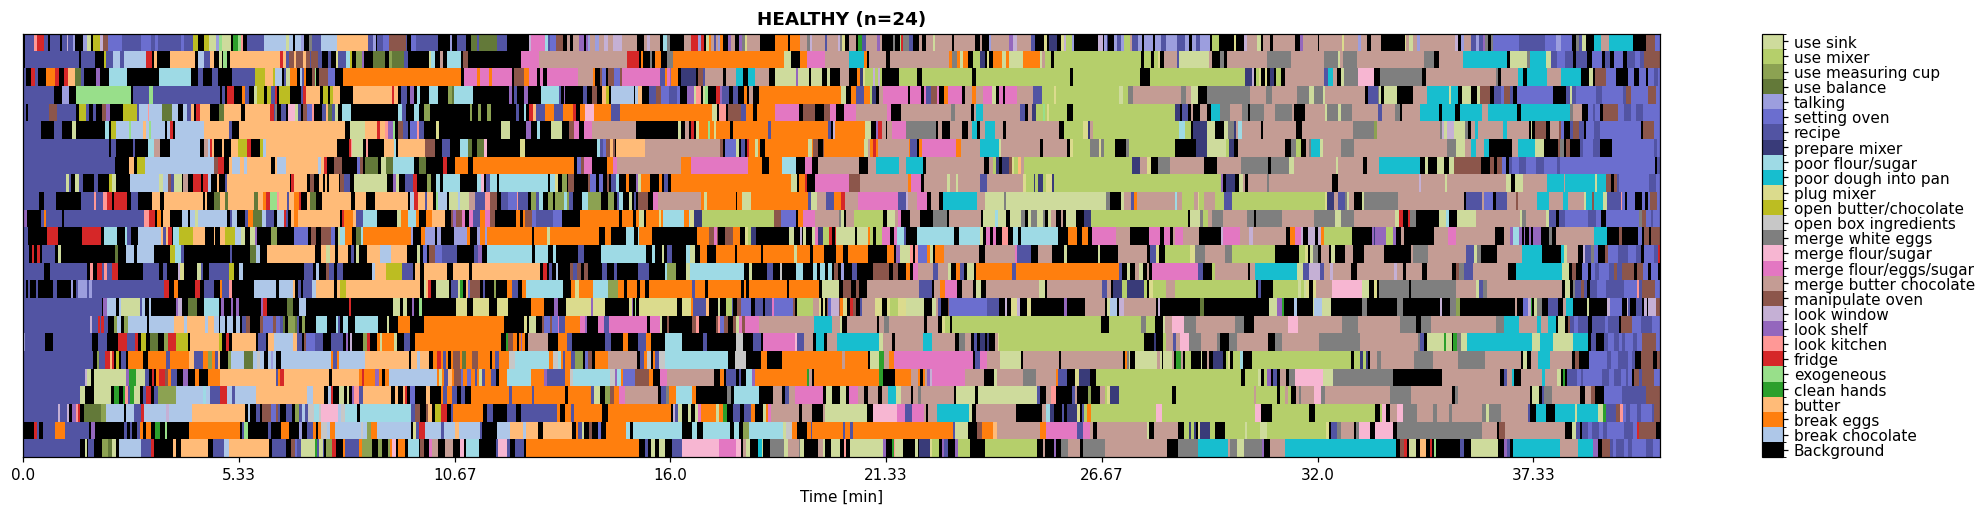

Mapping string labels to integers for visualization
dffds


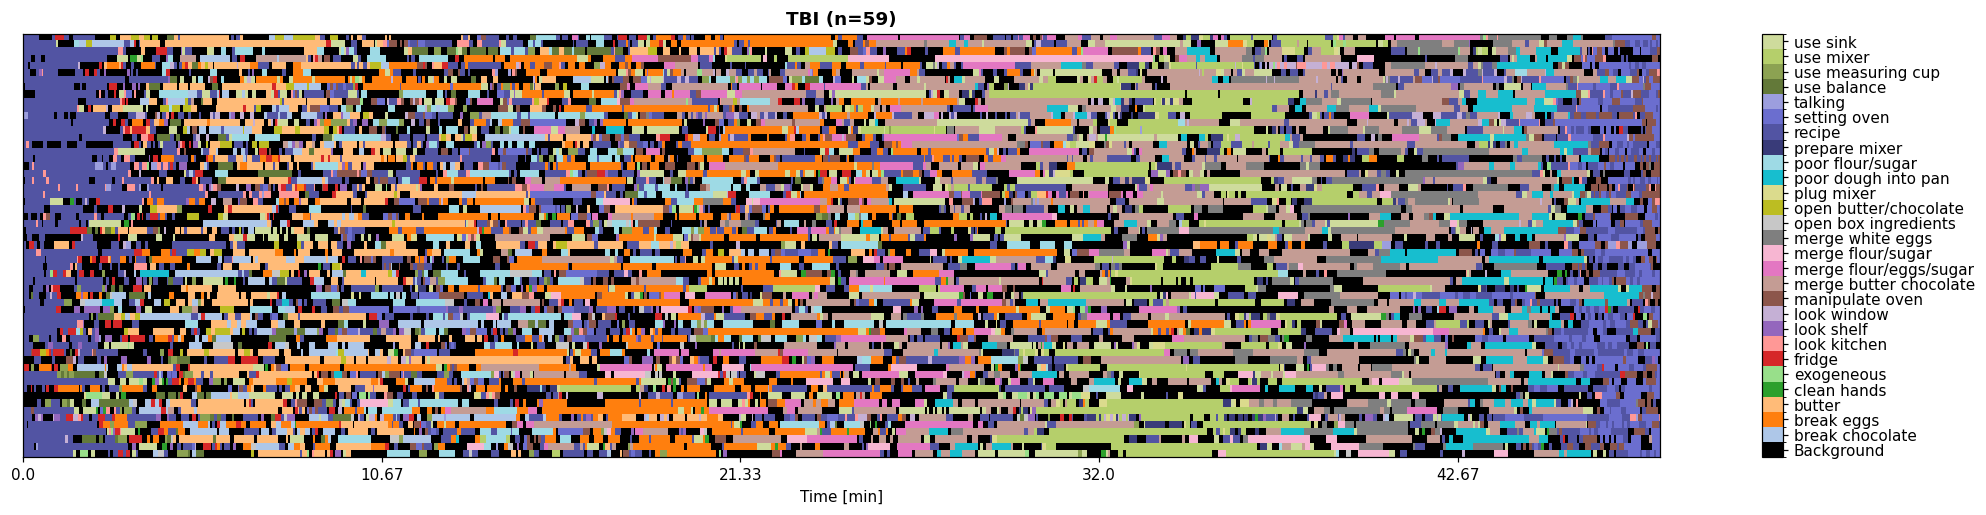

Mapping string labels to integers for visualization
dffds


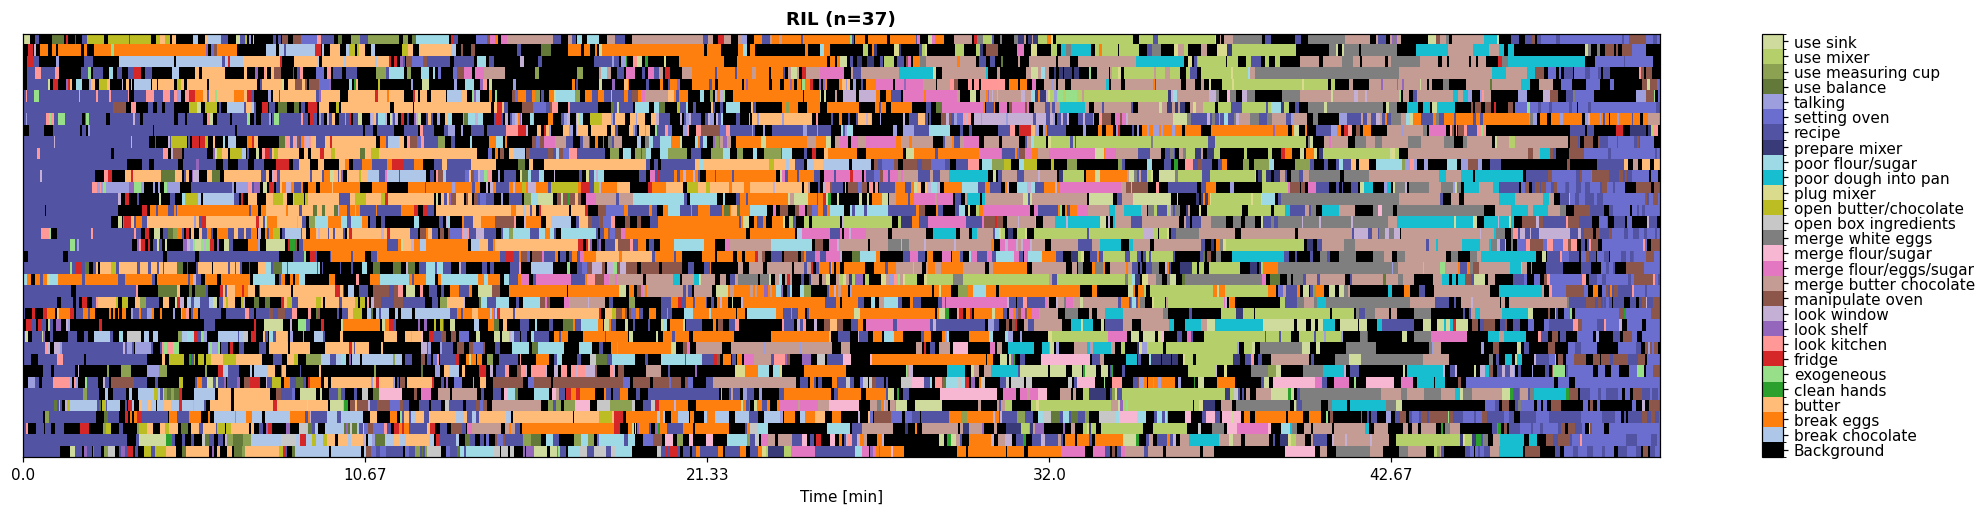

In [5]:
for g, name in [(0, 'HEALTHY'), (1, 'TBI'), (2, 'RIL')]:
    sub = df[df['group_folder'] == g]
    fig, ax = plt.subplots(figsize=(24, 5))
    plot_chronogames(sub, labels_col='cat_segm_embedding_labels', n_t_max=99999, time_calibration='embeddings',
                     cmap=cmap, norm=norm, boundaries=boundaries, mapping_labels_int=mapping_labels_int, ax=ax)
    ax.set_title('%s (n=%d)' % (name, len(sub)), weight='bold'); plt.show()

## (d) Pairwise TW-TWE (rTWE) distance matrix by group

Sequences interpolated to a common length, pairwise rTWE distance under the G=28 ground
cost, sorted by group. Reproduces the thesis distance-matrix figure.

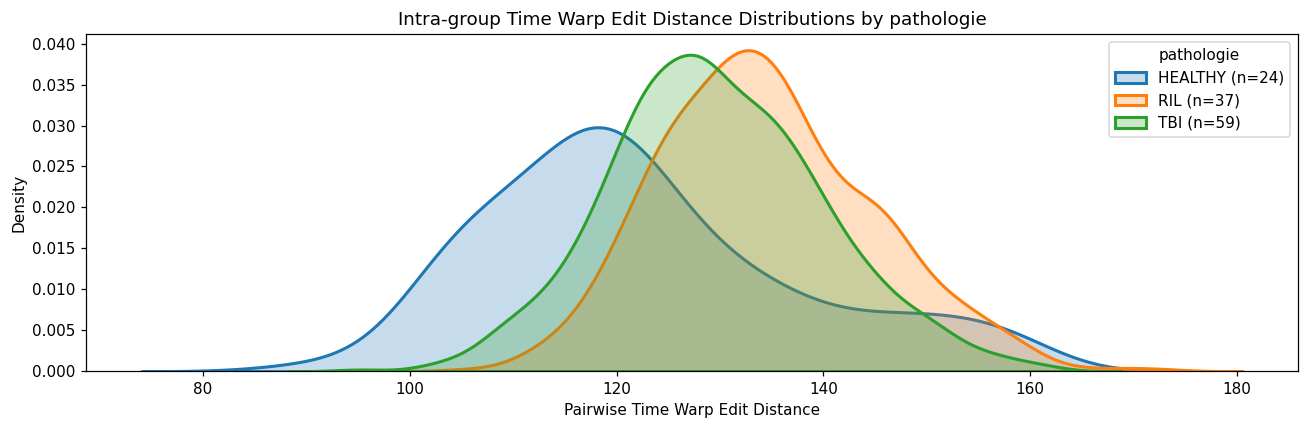

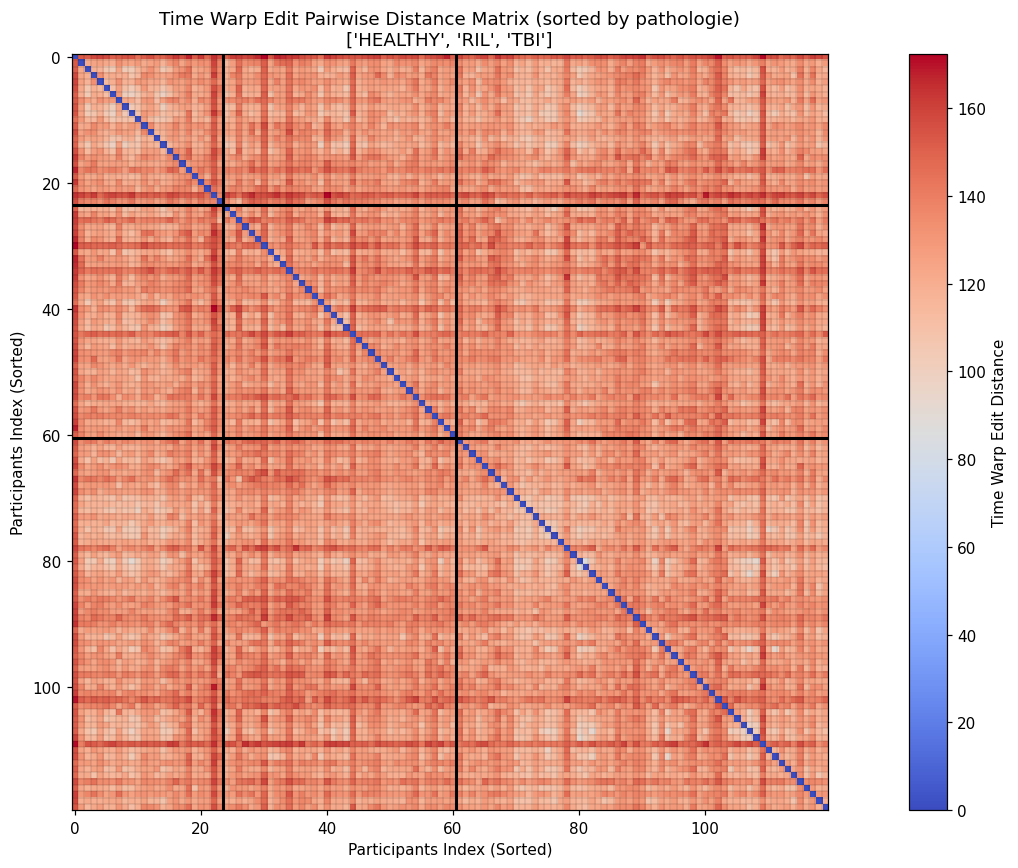

In [6]:
L_DIST = 400
Xd = np.vstack([upsample_sequence(np.asarray(s), L_DIST) for s in df['int_cat_segm_embedding_labels']]).astype(int)
D_pw = rtwe_pairwise_distance(Xd, nu=NU, lmbda=LMBDA, precomputed_distances=D_G_cat)
plot_pairwise_twe_distances_by_group(D_pw, df, covar_col='pathologie'); plt.show()

## (b) Per-group rTWE-DBA barycenters

Per-group barycenters via the forked aeon `elastic_barycenter_average` (`distance='rtwe'`,
`precomputed_distances=D_G`, `integers=True` → argmax / mode update), on sequences
interpolated to a common figure length. Each barycenter row retains the canonical temporal
phase structure of the cooking task. Reproduces the thesis barycenter chronogram.

In [7]:
barys = {}
for g, name in [(0, 'HEALTHY'), (1, 'TBI'), (2, 'RIL')]:
    sub = df[df['group_folder'] == g]
    Xg = np.vstack([upsample_sequence(np.asarray(s), FIG_L) for s in sub['int_cat_segm_embedding_labels']]).astype(int)
    idx_init, bary, best_cost, costs, idx_best = elastic_barycenter_average(
        Xg, method='petitjean', distance='rtwe', nu=NU, lmbda=LMBDA, init_barycenter='random',
        max_iters=20, tol=1e-7, precomputed_distances=D_G_cat, cmap=cmap, norm=norm,
        integers=True, verbose=False, random_state=0)
    barys[name] = np.asarray(bary).ravel().astype(int)
    print('%-8s barycenter L=%d  cost=%.1f' % (name, barys[name].size, best_cost))

HEALTHY  barycenter L=3000  cost=12883.3


TBI      barycenter L=3000  cost=35844.6


RIL      barycenter L=3000  cost=22985.5


Mapping string labels to integers for visualization
dffds


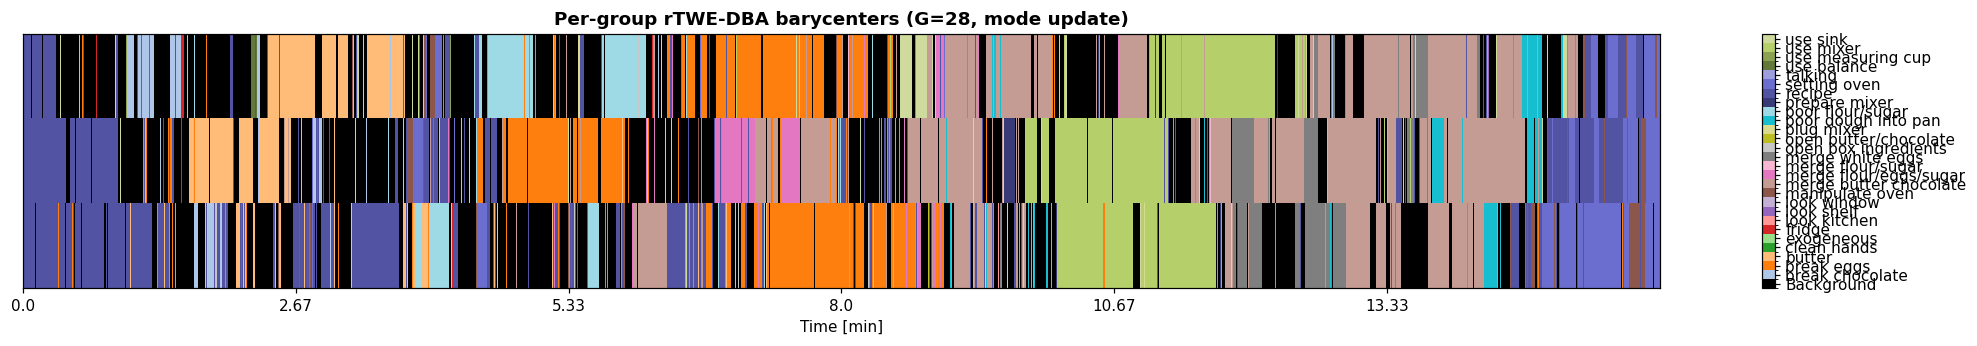

In [8]:
bdf = pd.DataFrame({
    'identifier': list(barys.keys()), 'modality': 'barycenter',
    'cat_segm_embedding_labels': [np.array([code_to_label[i] for i in s], dtype=object) for s in barys.values()]})
fig, ax = plt.subplots(figsize=(24, 3))
plot_chronogames(bdf, labels_col='cat_segm_embedding_labels', n_t_max=99999, time_calibration='embeddings',
                 cmap=cmap, norm=norm, boundaries=boundaries, mapping_labels_int=mapping_labels_int, ax=ax)
ax.set_title('Per-group rTWE-DBA barycenters (G=28, mode update)', weight='bold'); plt.show()

## (c) Alignment ribbons — `plot_chronogram_alignment`

rTWE optimal alignment between two sequences: `x` on top, `y` on bottom; the ribbon's
diagonal lines connect aligned positions (green = match, salmon = mismatch/addition,
light-green = background match), slope = temporal warp. Title shows the rTWE cost and the
match fraction. Reproduces the thesis alignment figure.

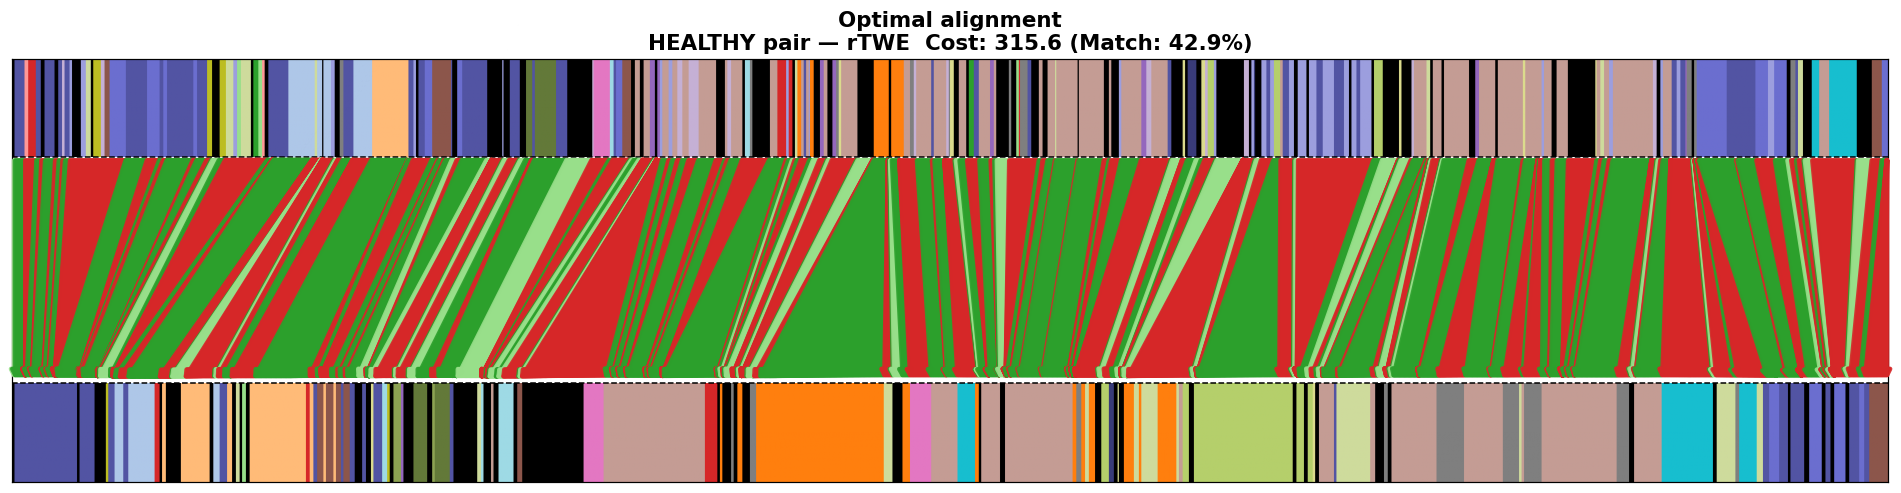

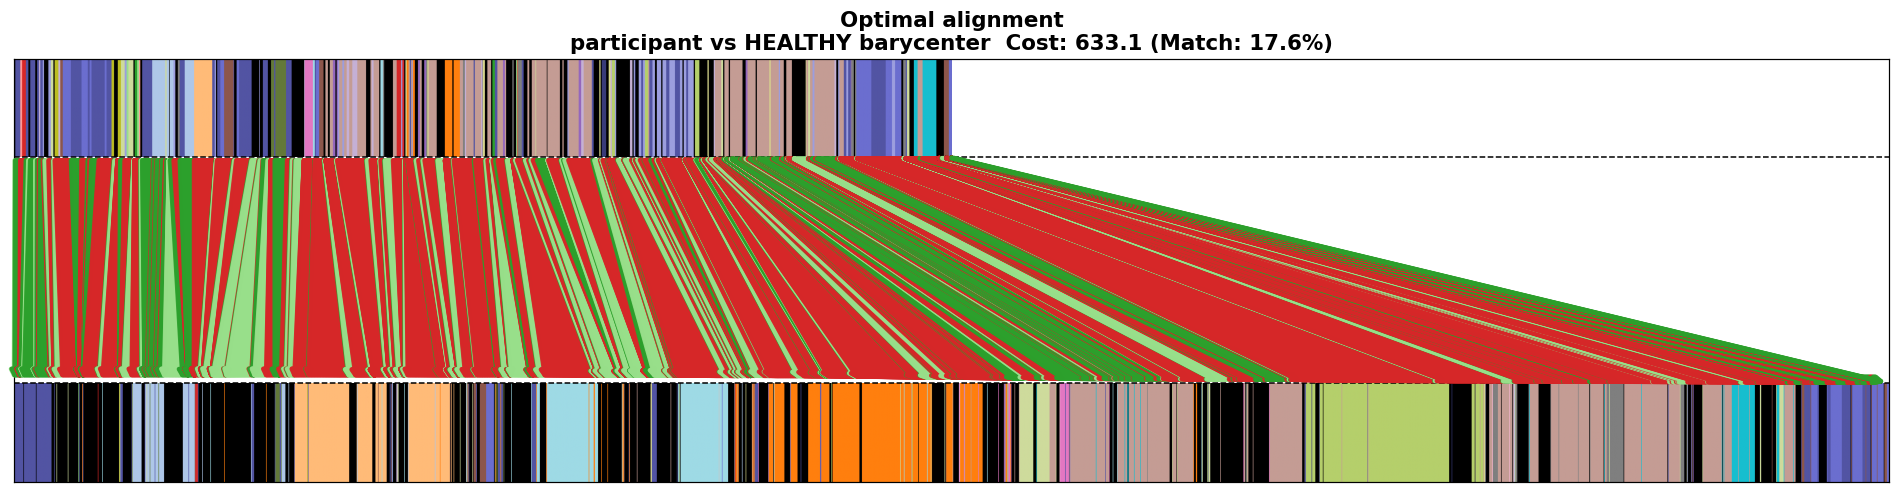

In [9]:
def show_alignment(xx, yy, ttl):
    p, d = compute_alignment_path('rtwe', xx, yy, D_G=D_G_cat, nu=NU, lmbda=LMBDA)
    fig, ax = plt.subplots(figsize=(22, 5))
    plot_chronogram_alignment(xx, yy, paths=p, method='rtwe', precomputed_distances=D_G_cat,
                              nu=NU, lmbda=LMBDA, title='%s  Cost: %.1f' % (ttl, d),
                              cmap=cmap, norm=norm, background_values=(0,), ax=ax)
    plt.show()

sub_h = df[df['group_folder'] == 0].reset_index(drop=True)
xa = upsample_sequence(np.asarray(sub_h['int_cat_segm_embedding_labels'].iloc[0]), ALN_L).astype(int)
xb = upsample_sequence(np.asarray(sub_h['int_cat_segm_embedding_labels'].iloc[1]), ALN_L).astype(int)
show_alignment(xa, xb, 'HEALTHY pair — rTWE')
show_alignment(xa, barys['HEALTHY'], 'participant vs HEALTHY barycenter')

## Classification re-assessment — does "frequency beats alignment" survive at longer L?

The previous 06c ran the 10×3-split AUC harness at `L=64`. Here we **sweep the resample
length** and compare the alignment-based methods (`k_medoid`, `tw_twe_mode`) against the
frequency baselines (`wasserstein` histogram, `majority_voting`). If the alignment methods'
AUC rises toward the frequency baselines as L grows, the `L=64` result was an artifact; if
it stays flat / below, the negative finding is robust. The train/test leakage guard
(`assert` in `evaluate_baselines`) is kept. Results are cached to `auc_vs_L_faithful.csv`.

In [10]:
labels = df['pathologie'].values.astype(object)
labels_pool = make_patient_control_labels(labels)

def methods_for(D_G):
    m = dict(B.default_baseline_methods(D_G, nu=NU, lmbda=LMBDA))
    for k in ['dba_dtw', 'soft_dtw']: m.pop(k, None)   # pure-python embedding methods: skip in the sweep
    m['tw_twe_mode'] = {'build': lambda X, seed: B.barycenter_mode_dba(X, D_G, nu=NU, lmbda=LMBDA),
                        'distance': lambda s, b: B.dist_neg_pmatch(s, b, D_G, nu=NU, lmbda=LMBDA)}
    return m

cache_auc = os.path.join(OUT, 'auc_vs_L_faithful.csv')
L_SWEEP = [64, 128, 256, 512, 1024]   # these cached L's include the O(L^2) alignment methods (tw_twe_mode
                                       # mode-DBA, edit_median); large-L numba safety = NUMBA_THREADING_LAYER
                                       # =workqueue (set in cell 1; the old "deadlock" was OMP + a forked kernel).
if os.path.exists(cache_auc):
    res = pd.read_csv(cache_auc); print('loaded cached AUC sweep:', sorted(res['L'].unique()))
else:
    rows = []
    for L in L_SWEEP:
        X = np.vstack([upsample_sequence(np.asarray(s), L) for s in df['int_cat_segm_embedding_labels']]).astype(int)
        Dpw = rtwe_pairwise_distance(X, nu=NU, lmbda=LMBDA, precomputed_distances=D_G_cat)
        meth = methods_for(D_G_cat)
        r1 = B.evaluate_baselines(X, labels, meth, D_pairwise=Dpw, n_splits=10, n_inits=3, random_state=42)
        r2 = B.evaluate_baselines(X, labels_pool, meth, D_pairwise=Dpw, n_splits=10, n_inits=3, random_state=42)
        rr = pd.concat([r1, r2], ignore_index=True); rr['L'] = L; rows.append(rr); print('L=%d done' % L)
    res = pd.concat(rows, ignore_index=True); res.to_csv(cache_auc, index=False)

# --- full embedding length (L≈5162): pairwise-cheap methods only ----------------------------
# tw_twe_mode (mode-DBA) and edit_median are O(L^2)/member here (a 10x3 eval ~1 h) -> GATED OFF.
# wasserstein/majority_voting/k_medoid need only the one-time (~3 min) pairwise rTWE matrix and are
# deterministic, so n_inits=1 is lossless. Appended so the cached L's above are never recomputed.
L_FULL = 5162; CHEAP = ['wasserstein', 'majority_voting', 'k_medoid']
if L_FULL not in set(res['L'].unique()):
    Xf = np.vstack([upsample_sequence(np.asarray(s), L_FULL) for s in df['int_cat_segm_embedding_labels']]).astype(int)
    Dpw = rtwe_pairwise_distance(Xf, nu=NU, lmbda=LMBDA, precomputed_distances=D_G_cat)
    meth = {k: v for k, v in methods_for(D_G_cat).items() if k in CHEAP}
    r1 = B.evaluate_baselines(Xf, labels, meth, D_pairwise=Dpw, n_splits=10, n_inits=1, random_state=42)
    r2 = B.evaluate_baselines(Xf, labels_pool, meth, D_pairwise=Dpw, n_splits=10, n_inits=1, random_state=42)
    rr = pd.concat([r1, r2], ignore_index=True); rr['L'] = L_FULL
    res = pd.concat([res, rr], ignore_index=True); res.to_csv(cache_auc, index=False)
    print('L=%d done (cheap only: %s)' % (L_FULL, CHEAP))
else:
    print('L=%d already cached' % L_FULL)

loaded cached AUC sweep: [64, 128, 256, 512, 1024]


L=5162 done (cheap only: ['wasserstein', 'majority_voting', 'k_medoid'])


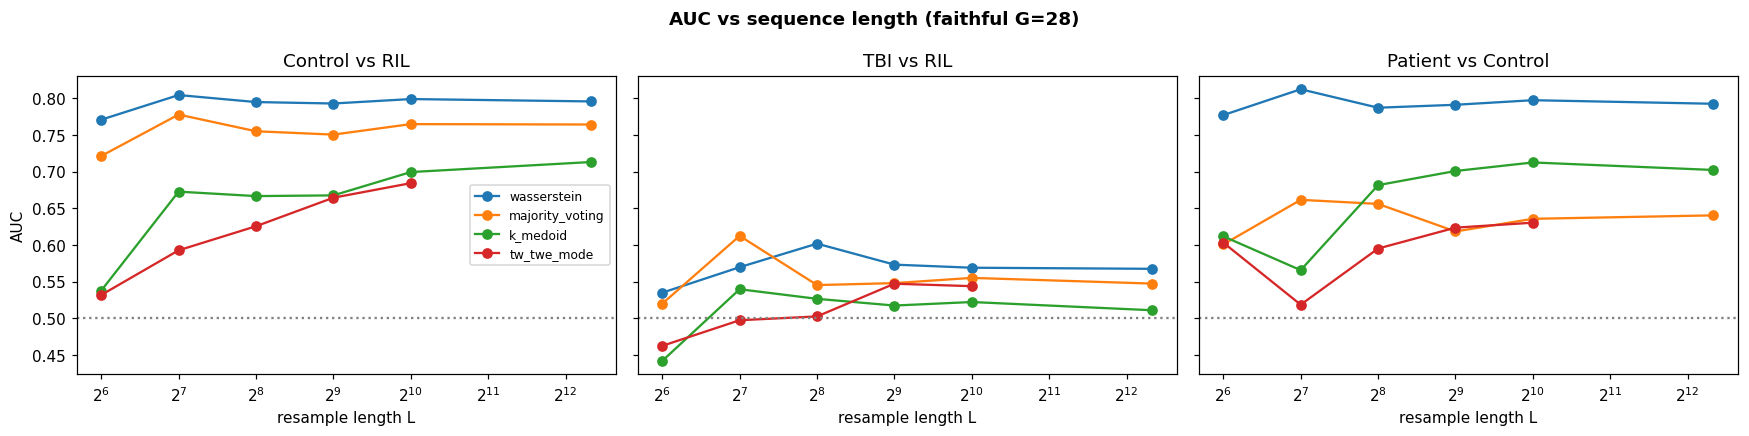

AUC at L=5162  (paper targets: Ctrl-vs-RIL 0.84, TBI-vs-RIL 0.59, Patient-vs-Ctrl 0.77)


comparison,HEALTHY_vs_RIL,RIL_vs_TBI,CONTROL_vs_PATIENT
method,,,
wasserstein,0.80±0.05,0.57±0.07,0.79±0.08
majority_voting,0.76±0.06,0.55±0.06,0.64±0.11
k_medoid,0.71±0.08,0.51±0.12,0.70±0.05


In [11]:
THREE = ['HEALTHY_vs_RIL', 'RIL_vs_TBI', 'CONTROL_vs_PATIENT']
TITLES = {'HEALTHY_vs_RIL': 'Control vs RIL', 'RIL_vs_TBI': 'TBI vs RIL', 'CONTROL_vs_PATIENT': 'Patient vs Control'}
KEEP = ['wasserstein', 'majority_voting', 'k_medoid', 'tw_twe_mode']
agg = res.groupby(['L', 'method', 'comparison'])['auc'].mean().reset_index()
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, comp in zip(axes, THREE):
    sub = agg[agg['comparison'] == comp]
    for m in KEEP:
        s = sub[sub['method'] == m].sort_values('L')
        if len(s): ax.plot(s['L'], s['auc'], 'o-', label=m)
    ax.axhline(0.5, color='gray', ls=':'); ax.set_title(TITLES[comp])
    ax.set_xlabel('resample length L'); ax.set_xscale('log', base=2)
axes[0].set_ylabel('AUC'); axes[0].legend(fontsize=8)
plt.suptitle('AUC vs sequence length (faithful G=28)', weight='bold'); plt.tight_layout(); plt.show()

Lmax = int(res['L'].max())
a2 = res[res['L'] == Lmax].groupby(['method', 'comparison'])['auc'].agg(['mean', 'std']).reset_index()
a2['cell'] = a2.apply(lambda r: f"{r['mean']:.2f}±{r['std']:.2f}", axis=1)
tab = a2.pivot(index='method', columns='comparison', values='cell').reindex([m for m in KEEP if m in a2['method'].unique()])
print('AUC at L=%d  (paper targets: Ctrl-vs-RIL 0.84, TBI-vs-RIL 0.59, Patient-vs-Ctrl 0.77)' % Lmax)
display(tab[[c for c in THREE if c in tab.columns]])

## Verdict

**The figures reproduce faithfully once `L=64` is removed.** On the embedding-level G=28
representation (median ≈ 5162 symbols/participant) the four thesis figure families —
cohort chronograms, per-group rTWE-DBA barycenters, `plot_chronogram_alignment` ribbons,
and the pairwise distance matrix — reproduce the thesis-era figures. The previous 06c
collapsed every sequence to a 64-cell strip, which is why its chronograms looked
segment-level.

**The classification re-assessment changes the previous conclusion in part.** Sweeping the
resample length `L` (10×3 stratified splits, native-distance scoring, train/test leakage
guarded) all the way to the full embedding length `L≈5162`. At `L≈5162` the O(L²)-per-member
alignment *barycenter* `tw_twe_mode` is gated off (a 10×3 eval there is ~1 h); only the
pairwise-cheap methods run (`n_inits=1`, lossless as they are deterministic):

| comparison | method | L=64 | 128 | 256 | 512 | 1024 | 5162 |
|---|---|---|---|---|---|---|---|
| Control vs RIL | `wasserstein` (freq.) | 0.77 | 0.80 | 0.80 | 0.79 | 0.80 | **0.80** |
| | `tw_twe_mode` (align. barycenter) | 0.53 | 0.59 | 0.63 | 0.66 | 0.68 | — |
| | `k_medoid` (align. exemplar) | 0.54 | 0.67 | 0.67 | 0.67 | 0.70 | **0.71** |
| Patient vs Control | `wasserstein` | 0.78 | 0.81 | 0.79 | 0.79 | 0.80 | **0.79** |
| | `k_medoid` | 0.61 | 0.57 | 0.68 | 0.70 | 0.71 | **0.70** |
| | `tw_twe_mode` | 0.60 | 0.52 | 0.60 | 0.62 | 0.63 | — |

1. **The alignment methods were crippled by `L=64`.** `tw_twe_mode` and `k_medoid` are
   near-chance at `L=64` and **rise monotonically with L**, recovering most of their
   discriminative power by `L≈512–1024`. So the earlier reproduction's *"the alignment
   barycenter is near-chance"* was substantially an **`L=64` resampling artifact**, not a
   property of the method.
2. **The headline claim holds — now confirmed at the full embedding length.** The
   symbol-frequency histogram (`wasserstein`) is **L-invariant** (~0.80 Control-vs-RIL,
   ~0.79–0.80 Patient-vs-Control) and **leads at every L through `L≈5162`**; the alignment
   exemplar `k_medoid` rose through the mid-L range but has **plateaued (~0.70–0.71), clearly
   below frequency**, by `L≈1024–5162` and never overtakes it. The frequency baseline
   reproduces the paper's headline (~0.77/0.84).

**Net:** the prior "frequency beats / alignment adds nothing" verdict is *qualitatively*
correct; its supporting "near-chance alignment" numbers were an `L=64` resampling artifact,
corrected here. **Full-length confirmation (closes 06c's prior open follow-up):** with the
rTWE kernel hardened in Session 2 (rolling-buffer + `prange` pairwise; full pairwise
n=120/L=5162 ≈ 3 min; `NUMBA_THREADING_LAYER=workqueue`), the sweep now reaches `L≈5162`
(pairwise-cheap methods only; mode-DBA gated as O(L²)-per-member). Frequency still leads and
the alignment exemplar plateaus below it — the **G=28 plateau is confirmed**, mirroring the
G=77 result (RESULTS_HANDOFF §13.2).